In [ ]:
# ============================================================
# Cell 1 — Load generated ABX3 feature dataset
# ============================================================
#Loss function for 0 ev things

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount("/content/drive")

FEATURE_PATH = "/content/drive/MyDrive/459/Project/ABX_Composition_Features_re/mp_general_abx3_composition_features.pkl"

if not os.path.exists(FEATURE_PATH):
    raise FileNotFoundError(f"Could not find file:\n{FEATURE_PATH}")

feature_df = pd.read_pickle(FEATURE_PATH)

print("Loaded feature dataframe:")
print(feature_df.shape)

display(feature_df.head())

Mounted at /content/drive
Loaded feature dataframe:
(1719, 166)


,A_like_Z,A_like_mass,A_like_en,A_like_row,A_like_group,A_like_mendeleev,A_like_atomic_radius,A_like_atomic_radius_calculated,A_like_van_der_waals_radius,A_like_melting_point,...,A_like,B_like,X_like,band_gap,energy_above_hull,formation_energy_per_atom,is_stable,theoretical,is_metal,total_magnetization
0,20,40.0780,1.00,4,2,16.0,1.80,1.94,2.31,1115.00,...,Ca,Fe,O,0.0000,0.052147,-2.176372,False,True,True,4.060209
1,19,39.0983,0.82,4,1,10.0,2.20,2.43,2.75,336.53,...,K,Co,Cl,0.0000,0.087748,-1.427099,False,True,True,6.002419
2,82,207.2000,2.33,6,14,82.0,1.80,1.54,2.02,600.61,...,Pb,H,I,0.0000,0.663116,0.037986,False,True,True,1.201316
3,72,178.4900,1.30,6,4,50.0,1.55,2.08,2.23,2506.00,...,Hf,Zn,O,0.0000,0.687029,-2.441217,False,True,True,0.012388
4,12,24.3050,1.31,3,2,73.0,1.50,1.45,1.73,923.00,...,Mg,Sn,O,1.3084,0.629875,-1.866468,False,True,False,0.000471


In [ ]:
# ============================================================
# Cell 3 — Define X feature matrix
# ============================================================

non_feature_cols = [
    "material_id",
    "formula",
    "A_like",
    "B_like",
    "X_like",
    "band_gap",
    "energy_above_hull",
    "formation_energy_per_atom",
    "is_stable",
    "theoretical",
    "is_metal",
]

feature_cols = [
    col for col in feature_df.columns
    if col not in non_feature_cols
]

X = feature_df[feature_cols].copy()

# Keep only numeric columns
X = X.select_dtypes(include=[np.number, bool]).copy()

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

print("Feature matrix X:")
print(X.shape)

display(X.head())

Feature matrix X:
(1719, 155)


,A_like_Z,A_like_mass,A_like_en,A_like_row,A_like_group,A_like_mendeleev,A_like_atomic_radius,A_like_atomic_radius_calculated,A_like_van_der_waals_radius,A_like_melting_point,...,abs_A_minus_X_en,abs_A_minus_B_en,B_over_X_atomic_radius,A_over_X_atomic_radius,A_over_B_atomic_radius,radius_tolerance_proxy,octahedral_radius_proxy,calc_radius_tolerance_proxy,calc_octahedral_radius_proxy,total_magnetization
0,20,40.0780,1.00,4,2,16.0,1.80,1.94,2.31,1115.00,...,2.44,0.83,2.333333,3.000000,1.285714,0.848528,2.333333,0.838823,3.250000,4.060209
1,19,39.0983,0.82,4,1,10.0,2.20,2.43,2.75,336.53,...,2.34,1.06,1.350000,2.200000,1.629630,0.962869,1.350000,0.985664,1.924051,6.002419
2,82,207.2000,2.33,6,14,82.0,1.80,1.54,2.02,600.61,...,0.33,0.13,0.178571,1.285714,7.200000,1.371359,0.178571,1.132213,0.460870,1.201316
3,72,178.4900,1.30,6,4,50.0,1.55,2.08,2.23,2506.00,...,2.14,0.35,2.250000,2.583333,1.148148,0.779631,2.250000,0.952733,2.958333,0.012388
4,12,24.3050,1.31,3,2,73.0,1.50,1.45,1.73,923.00,...,2.13,0.65,2.416667,2.500000,1.034483,0.724353,2.416667,0.707107,3.020833,0.000471


In [ ]:
# ============================================================
# Cell 4 — Helper function for RF modeling
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_rf_model(target_col, test_size=0.20, random_state=42):
    """
    Train RF model for a selected target column.
    """

    if target_col not in feature_df.columns:
        raise ValueError(f"{target_col} not found in feature_df.")

    y = feature_df[target_col].copy()

    valid_idx = y.dropna().index

    X_valid = X.loc[valid_idx].copy()
    y_valid = y.loc[valid_idx].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_valid,
        y_valid,
        test_size=test_size,
        random_state=random_state
    )

    scaler = StandardScaler()

    X_train_scaled_array = scaler.fit_transform(X_train)
    X_test_scaled_array = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled_array,
        columns=X_valid.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        X_test_scaled_array,
        columns=X_valid.columns,
        index=X_test.index
    )

    rf = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1
    )

    rf.fit(X_train_scaled, y_train)

    y_pred = rf.predict(X_test_scaled)

    metrics = {
        "target": target_col,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "num_samples": len(y_valid),
        "num_features": X_valid.shape[1],
    }

    result = {
        "target_col": target_col,
        "model": rf,
        "scaler": scaler,
        "X_train": X_train,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "metrics": metrics,
        "feature_cols": X_valid.columns.tolist(),
    }

    return result

In [ ]:
# ============================================================
# Cell 5 — Train band gap model
# ============================================================

bandgap_result = train_rf_model("band_gap")

print("Band gap RF model")
print("MAE:", bandgap_result["metrics"]["MAE"], "eV")
print("RMSE:", bandgap_result["metrics"]["RMSE"], "eV")
print("R2:", bandgap_result["metrics"]["R2"])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Band gap RF model
MAE: 0.4154744136294027 eV
RMSE: 0.6545200405655086 eV
R2: 0.8293304849953118


In [ ]:
# ============================================================
# Cell 6 — Train energy above hull model
# ============================================================

hull_result = train_rf_model("energy_above_hull")

print("Energy above hull RF model")
print("MAE:", hull_result["metrics"]["MAE"], "eV/atom")
print("RMSE:", hull_result["metrics"]["RMSE"], "eV/atom")
print("R2:", hull_result["metrics"]["R2"])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Energy above hull RF model
MAE: 0.13075844901354894 eV/atom
RMSE: 0.2059492246694819 eV/atom
R2: 0.6384916604433373


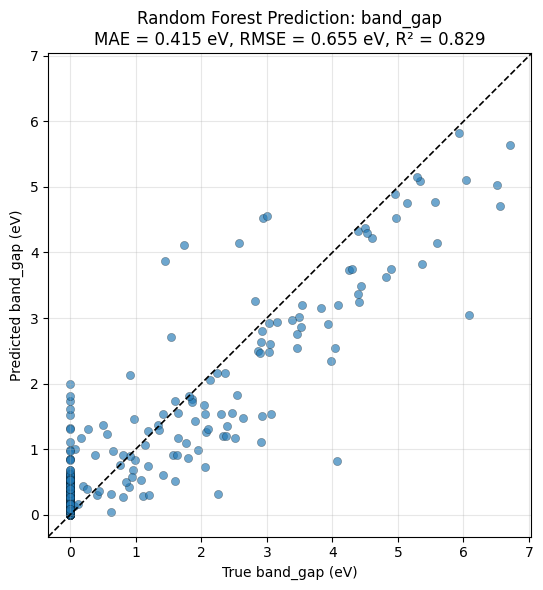

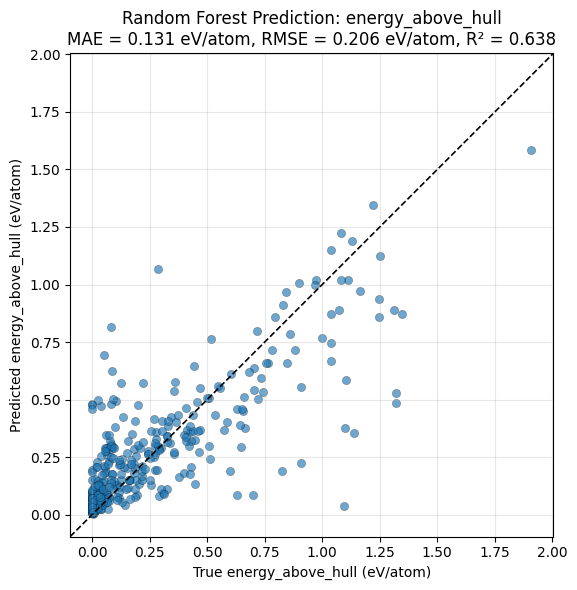

In [ ]:
# ============================================================
# Cell 8 — Predicted vs true plots
# ============================================================

def plot_predicted_vs_true(result, unit):
    target_col = result["target_col"]
    y_test = result["y_test"]
    y_pred = result["y_pred"]
    metrics = result["metrics"]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.25
    )

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    pad = 0.05 * (max_val - min_val)

    lower = min_val - pad
    upper = max_val + pad

    plt.plot(
        [lower, upper],
        [lower, upper],
        "k--",
        linewidth=1.2
    )

    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"True {target_col} ({unit})")
    plt.ylabel(f"Predicted {target_col} ({unit})")

    plt.title(
        f"Random Forest Prediction: {target_col}\n"
        f"MAE = {metrics['MAE']:.3f} {unit}, "
        f"RMSE = {metrics['RMSE']:.3f} {unit}, "
        f"R² = {metrics['R2']:.3f}"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_predicted_vs_true(bandgap_result, "eV")
plot_predicted_vs_true(hull_result, "eV/atom")

## We will do gridsearch from here to redo optimization

In [ ]:
# ============================================================
# Cell 5 — Manual CV grid search for band gap
# Metrics:
# 1. RMSE over all band gaps
# 2. RMSE only for true band gap < 0.5 eV
# ============================================================

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

target_col = "band_gap"
low_gap_cutoff = 0.5

y = feature_df[target_col].copy()

valid_idx = y.dropna().index

X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

# Final held-out test split
# The CV heatmaps are generated only from X_train/y_train
X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.20,
    random_state=42
)

n_estimators_grid = [10, 20, 40, 80, 160, 320]
min_samples_leaf_grid = [1, 2, 4, 8, 16]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_results = []

for n_estimators in n_estimators_grid:
    for min_leaf in min_samples_leaf_grid:

        fold_all_rmse = []
        fold_low_rmse = []
        fold_low_counts = []

        for train_idx, val_idx in kf.split(X_train):

            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]

            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]

            # Normalize inside each fold to avoid leakage
            scaler = StandardScaler()

            X_fold_train_scaled = scaler.fit_transform(X_fold_train)
            X_fold_val_scaled = scaler.transform(X_fold_val)

            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                min_samples_leaf=min_leaf,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )

            rf.fit(X_fold_train_scaled, y_fold_train)

            y_val_pred = rf.predict(X_fold_val_scaled)

            # General RMSE over all validation band gaps
            rmse_all = np.sqrt(
                mean_squared_error(y_fold_val, y_val_pred)
            )

            fold_all_rmse.append(rmse_all)

            # Low-band-gap RMSE: only where true band gap < 0.5 eV
            low_mask = y_fold_val < low_gap_cutoff
            low_count = low_mask.sum()
            fold_low_counts.append(low_count)

            if low_count > 0:
                rmse_low = np.sqrt(
                    mean_squared_error(
                        y_fold_val[low_mask],
                        y_val_pred[low_mask]
                    )
                )
            else:
                rmse_low = np.nan

            fold_low_rmse.append(rmse_low)

        grid_results.append({
            "n_estimators": n_estimators,
            "min_samples_leaf": min_leaf,

            "mean_all_RMSE": np.mean(fold_all_rmse),
            "std_all_RMSE": np.std(fold_all_rmse),

            "mean_low_gap_RMSE": np.nanmean(fold_low_rmse),
            "std_low_gap_RMSE": np.nanstd(fold_low_rmse),

            "total_low_gap_val_count": np.sum(fold_low_counts),
            "fold_low_gap_counts": fold_low_counts,
        })

grid_results_df = pd.DataFrame(grid_results)

print("Grid search complete.")
display(grid_results_df.sort_values("mean_all_RMSE").head(10))
display(grid_results_df.sort_values("mean_low_gap_RMSE").head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unno

Grid search complete.


,n_estimators,min_samples_leaf,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,fold_low_gap_counts
26,320,2,0.718213,0.049312,0.535320,0.082702,932,"[188, 175, 184, 195, 190]"
25,320,1,0.718682,0.047194,0.542635,0.096137,932,"[188, 175, 184, 195, 190]"
20,160,1,0.719370,0.042443,0.541772,0.094725,932,"[188, 175, 184, 195, 190]"
21,160,2,0.721916,0.048342,0.539527,0.081023,932,"[188, 175, 184, 195, 190]"
15,80,1,0.722451,0.036550,0.547043,0.087226,932,"[188, 175, 184, 195, 190]"
16,80,2,0.723325,0.046076,0.539536,0.077154,932,"[188, 175, 184, 195, 190]"
11,40,2,0.727513,0.042154,0.549327,0.083506,932,"[188, 175, 184, 195, 190]"
10,40,1,0.728576,0.038471,0.549596,0.087171,932,"[188, 175, 184, 195, 190]"
5,20,1,0.730692,0.034375,0.554747,0.090581,932,"[188, 175, 184, 195, 190]"
27,320,4,0.736230,0.058428,0.541740,0.077134,932,"[188, 175, 184, 195, 190]"


,n_estimators,min_samples_leaf,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,fold_low_gap_counts
26,320,2,0.718213,0.049312,0.535320,0.082702,932,"[188, 175, 184, 195, 190]"
17,80,4,0.736782,0.057511,0.536919,0.070707,932,"[188, 175, 184, 195, 190]"
22,160,4,0.737615,0.061203,0.537803,0.073671,932,"[188, 175, 184, 195, 190]"
21,160,2,0.721916,0.048342,0.539527,0.081023,932,"[188, 175, 184, 195, 190]"
16,80,2,0.723325,0.046076,0.539536,0.077154,932,"[188, 175, 184, 195, 190]"
27,320,4,0.736230,0.058428,0.541740,0.077134,932,"[188, 175, 184, 195, 190]"
20,160,1,0.719370,0.042443,0.541772,0.094725,932,"[188, 175, 184, 195, 190]"
25,320,1,0.718682,0.047194,0.542635,0.096137,932,"[188, 175, 184, 195, 190]"
15,80,1,0.722451,0.036550,0.547043,0.087226,932,"[188, 175, 184, 195, 190]"
12,40,4,0.748531,0.054481,0.547171,0.077097,932,"[188, 175, 184, 195, 190]"


n_estimators,10,20,40,80,160,320
min_samples_leaf,,,,,,
1,0.743103,0.730692,0.728576,0.722451,0.719370,0.718682
2,0.759533,0.737476,0.727513,0.723325,0.721916,0.718213
4,0.758930,0.758260,0.748531,0.736782,0.737615,0.736230
8,0.791201,0.796268,0.787008,0.780154,0.780572,0.780447
16,0.873734,0.881146,0.879808,0.863340,0.864925,0.864428


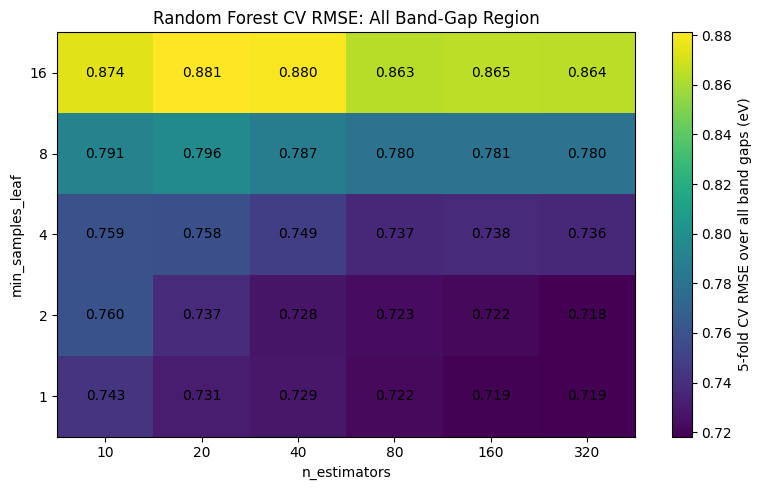

In [ ]:
# ============================================================
# Cell 6 — Heatmap: general CV RMSE over all band gaps
# ============================================================

import matplotlib.pyplot as plt

heatmap_all = grid_results_df.pivot(
    index="min_samples_leaf",
    columns="n_estimators",
    values="mean_all_RMSE"
)

display(heatmap_all)

plt.figure(figsize=(8, 5))

plt.imshow(
    heatmap_all,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="5-fold CV RMSE over all band gaps (eV)")

plt.xticks(
    ticks=np.arange(len(heatmap_all.columns)),
    labels=heatmap_all.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_all.index)),
    labels=heatmap_all.index
)

plt.xlabel("n_estimators")
plt.ylabel("min_samples_leaf")
plt.title("Random Forest CV RMSE: All Band-Gap Region")

for i in range(len(heatmap_all.index)):
    for j in range(len(heatmap_all.columns)):
        value = heatmap_all.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

n_estimators,10,20,40,80,160,320
min_samples_leaf,,,,,,
1,0.568484,0.554747,0.549596,0.547043,0.541772,0.542635
2,0.582753,0.553477,0.549327,0.539536,0.539527,0.535320
4,0.569205,0.555224,0.547171,0.536919,0.537803,0.541740
8,0.567182,0.565417,0.561558,0.552339,0.555034,0.557483
16,0.598326,0.594205,0.597141,0.588875,0.590214,0.591949


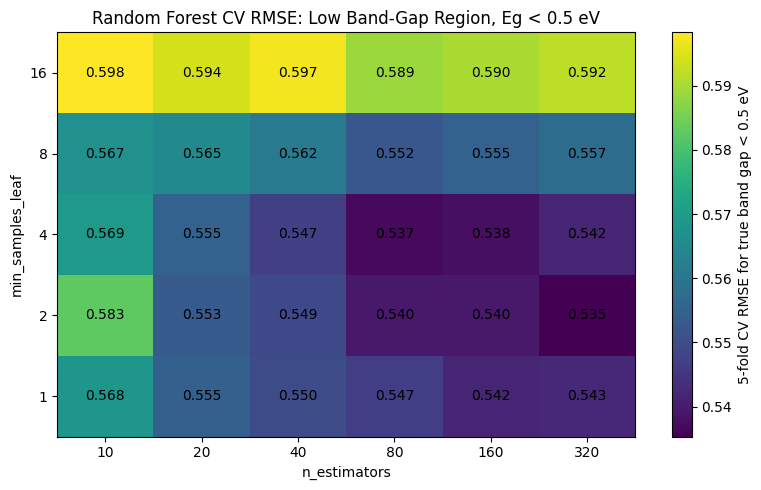

In [ ]:
# ============================================================
# Cell 7 — Heatmap: CV RMSE for true band gap < 0.5 eV
# ============================================================

heatmap_low = grid_results_df.pivot(
    index="min_samples_leaf",
    columns="n_estimators",
    values="mean_low_gap_RMSE"
)

display(heatmap_low)

plt.figure(figsize=(8, 5))

plt.imshow(
    heatmap_low,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="5-fold CV RMSE for true band gap < 0.5 eV")

plt.xticks(
    ticks=np.arange(len(heatmap_low.columns)),
    labels=heatmap_low.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_low.index)),
    labels=heatmap_low.index
)

plt.xlabel("n_estimators")
plt.ylabel("min_samples_leaf")
plt.title("Random Forest CV RMSE: Low Band-Gap Region, Eg < 0.5 eV")

for i in range(len(heatmap_low.index)):
    for j in range(len(heatmap_low.columns)):
        value = heatmap_low.iloc[i, j]

        if np.isnan(value):
            text = "NaN"
        else:
            text = f"{value:.3f}"

        plt.text(
            j,
            i,
            text,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RMSE vs n_estimators at min_samples_leaf = 1
# Metrics:
# 1. General RMSE over all band gaps
# 2. Low-band-gap RMSE where true band_gap < 0.5 eV
# ============================================================

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target_col = "band_gap"
low_gap_cutoff = 0.5

n_estimators_list = [300, 400, 450, 500, 550, 650]
min_leaf = 2

# Define target
y = feature_df[target_col].copy()

# Keep rows with target
valid_idx = y.dropna().index

X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

# Hold out final test set
X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.20,
    random_state=42
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

n_tree_results = []

for n_estimators in n_estimators_list:

    fold_all_rmse = []
    fold_low_rmse = []
    fold_low_counts = []

    for train_idx, val_idx in kf.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Normalize inside each CV fold
        scaler = StandardScaler()

        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler.transform(X_fold_val)

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            min_samples_leaf=min_leaf,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_fold_train_scaled, y_fold_train)

        y_val_pred = rf.predict(X_fold_val_scaled)

        # RMSE over all validation band gaps
        rmse_all = np.sqrt(
            mean_squared_error(y_fold_val, y_val_pred)
        )

        fold_all_rmse.append(rmse_all)

        # RMSE only where true band gap < 0.5 eV
        low_mask = y_fold_val < low_gap_cutoff
        low_count = low_mask.sum()
        fold_low_counts.append(low_count)

        if low_count > 0:
            rmse_low = np.sqrt(
                mean_squared_error(
                    y_fold_val[low_mask],
                    y_val_pred[low_mask]
                )
            )
        else:
            rmse_low = np.nan

        fold_low_rmse.append(rmse_low)

    n_tree_results.append({
        "n_estimators": n_estimators,
        "min_samples_leaf": min_leaf,

        "mean_all_RMSE": np.mean(fold_all_rmse),
        "std_all_RMSE": np.std(fold_all_rmse),

        "mean_low_gap_RMSE": np.nanmean(fold_low_rmse),
        "std_low_gap_RMSE": np.nanstd(fold_low_rmse),

        "total_low_gap_val_count": np.sum(fold_low_counts),
        "fold_low_gap_counts": fold_low_counts,
    })

n_tree_results_df = pd.DataFrame(n_tree_results)

display(n_tree_results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unno

,n_estimators,min_samples_leaf,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,fold_low_gap_counts
0,300,2,0.719203,0.050210,0.536017,0.082344,932,"[188, 175, 184, 195, 190]"
1,400,2,0.716944,0.049407,0.532503,0.081403,932,"[188, 175, 184, 195, 190]"
2,450,2,0.717266,0.050594,0.532212,0.081472,932,"[188, 175, 184, 195, 190]"
3,500,2,0.717365,0.051736,0.531594,0.083295,932,"[188, 175, 184, 195, 190]"
4,550,2,0.716942,0.051659,0.532015,0.083255,932,"[188, 175, 184, 195, 190]"
5,650,2,0.716941,0.050319,0.533830,0.083869,932,"[188, 175, 184, 195, 190]"


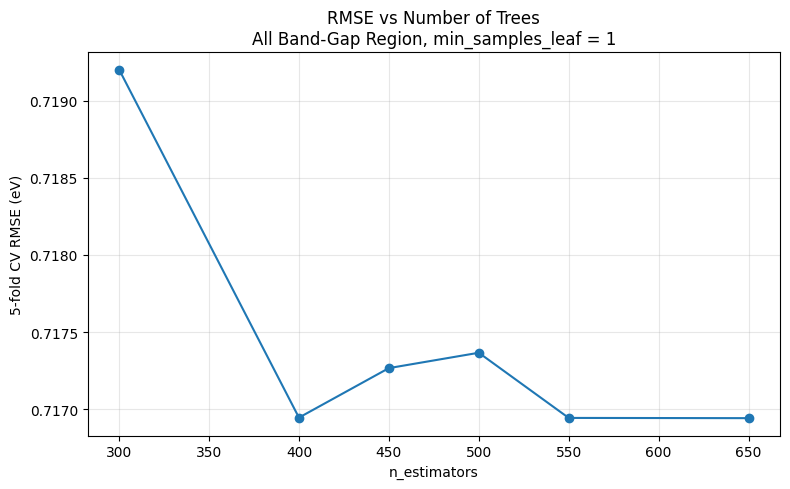

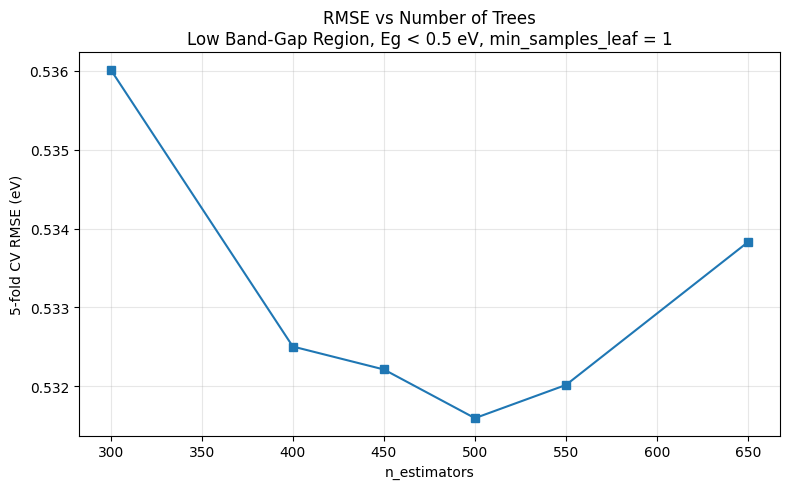

In [ ]:
# ============================================================
# Separate plots
# ============================================================

# All band gaps
plt.figure(figsize=(8, 5))

plt.plot(
    n_tree_results_df["n_estimators"],
    n_tree_results_df["mean_all_RMSE"],
    marker="o"
)

plt.xlabel("n_estimators")
plt.ylabel("5-fold CV RMSE (eV)")
plt.title("RMSE vs Number of Trees\nAll Band-Gap Region, min_samples_leaf = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Low band gaps
plt.figure(figsize=(8, 5))

plt.plot(
    n_tree_results_df["n_estimators"],
    n_tree_results_df["mean_low_gap_RMSE"],
    marker="s"
)

plt.xlabel("n_estimators")
plt.ylabel("5-fold CV RMSE (eV)")
plt.title("RMSE vs Number of Trees\nLow Band-Gap Region, Eg < 0.5 eV, min_samples_leaf = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LASSO + RF GridSearchCV after RF grid search

In [ ]:
# ============================================================
# LASSO + RF GridSearchCV after RF grid search
# Hyperparameters:
#   LassoCV n_alphas: 10, 30, 50
#   LassoCV max_iter: 10000
#
# Fixed RF:
#   n_estimators = 200
#   min_samples_leaf = 1
#
# Metrics:
#   1. 5-fold CV RMSE over all band gaps
#   2. 5-fold CV RMSE for true band_gap < 0.5 eV
# ============================================================

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

target_col = "band_gap"
low_gap_cutoff = 0.5

# LASSO grid
n_alphas_grid = [30, 50]
max_iter_grid = [500, 1000, 2000]

# Fixed RF condition
fixed_rf_n_estimators = 400
fixed_rf_min_samples_leaf = 2

# ------------------------------------------------------------
# Prepare X/y
# ------------------------------------------------------------

y = feature_df[target_col].copy()
valid_idx = y.dropna().index

X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

# Replace inf with NaN
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)

# Drop all-NaN columns before splitting
all_nan_cols = X_valid.columns[X_valid.isna().all()].tolist()

if len(all_nan_cols) > 0:
    print("Dropping all-NaN columns:", all_nan_cols)
    X_valid = X_valid.drop(columns=all_nan_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.20,
    random_state=42
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lasso_rf_grid_results = []

for n_alphas in n_alphas_grid:
    for max_iter in max_iter_grid:

        print(f"Running LASSO + RF: n_alphas={n_alphas}, max_iter={max_iter}")

        fold_all_rmse = []
        fold_low_rmse = []
        fold_low_counts = []
        fold_selected_counts = []
        fold_lasso_alphas = []

        for train_idx, val_idx in kf.split(X_train):

            X_fold_train = X_train.iloc[train_idx].copy()
            X_fold_val = X_train.iloc[val_idx].copy()

            y_fold_train = y_train.iloc[train_idx].copy()
            y_fold_val = y_train.iloc[val_idx].copy()

            # ------------------------------------------------
            # Impute inside each fold to avoid leakage
            # ------------------------------------------------

            imputer = SimpleImputer(strategy="median")

            X_fold_train_imputed = pd.DataFrame(
                imputer.fit_transform(X_fold_train),
                columns=X_fold_train.columns,
                index=X_fold_train.index
            )

            X_fold_val_imputed = pd.DataFrame(
                imputer.transform(X_fold_val),
                columns=X_fold_val.columns,
                index=X_fold_val.index
            )

            # ------------------------------------------------
            # Normalize inside each fold to avoid leakage
            # ------------------------------------------------

            scaler = StandardScaler()

            X_fold_train_scaled = pd.DataFrame(
                scaler.fit_transform(X_fold_train_imputed),
                columns=X_fold_train_imputed.columns,
                index=X_fold_train_imputed.index
            )

            X_fold_val_scaled = pd.DataFrame(
                scaler.transform(X_fold_val_imputed),
                columns=X_fold_val_imputed.columns,
                index=X_fold_val_imputed.index
            )

            # ------------------------------------------------
            # LASSO feature selection
            # ------------------------------------------------

            lasso = LassoCV(
                cv=5,
                n_alphas=n_alphas,
                max_iter=max_iter,
                tol=1e-3,
                random_state=42,
                n_jobs=-1
            )

            lasso.fit(X_fold_train_scaled, y_fold_train)

            lasso_coef = pd.Series(
                lasso.coef_,
                index=X_fold_train_scaled.columns
            )

            selected_features = lasso_coef[lasso_coef != 0].index.tolist()

            # Fallback if LASSO selects zero features
            if len(selected_features) == 0:
                selected_features = (
                    lasso_coef.abs()
                    .sort_values(ascending=False)
                    .head(20)
                    .index
                    .tolist()
                )

            fold_selected_counts.append(len(selected_features))
            fold_lasso_alphas.append(lasso.alpha_)

            X_fold_train_lasso = X_fold_train_scaled[selected_features].copy()
            X_fold_val_lasso = X_fold_val_scaled[selected_features].copy()

            # ------------------------------------------------
            # Fixed RF
            # ------------------------------------------------

            rf = RandomForestRegressor(
                n_estimators=fixed_rf_n_estimators,
                min_samples_leaf=fixed_rf_min_samples_leaf,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )

            rf.fit(X_fold_train_lasso, y_fold_train)

            y_val_pred = rf.predict(X_fold_val_lasso)

            # RMSE over all validation band gaps
            rmse_all = np.sqrt(
                mean_squared_error(y_fold_val, y_val_pred)
            )

            fold_all_rmse.append(rmse_all)

            # RMSE only for true band_gap < 0.5 eV
            low_mask = y_fold_val < low_gap_cutoff
            low_count = int(low_mask.sum())

            fold_low_counts.append(low_count)

            if low_count > 0:
                rmse_low = np.sqrt(
                    mean_squared_error(
                        y_fold_val[low_mask],
                        y_val_pred[low_mask]
                    )
                )
            else:
                rmse_low = np.nan

            fold_low_rmse.append(rmse_low)

        lasso_rf_grid_results.append({
            "n_alphas": n_alphas,
            "max_iter": max_iter,

            "mean_all_RMSE": np.mean(fold_all_rmse),
            "std_all_RMSE": np.std(fold_all_rmse),

            "mean_low_gap_RMSE": np.nanmean(fold_low_rmse),
            "std_low_gap_RMSE": np.nanstd(fold_low_rmse),

            "total_low_gap_val_count": np.sum(fold_low_counts),
            "mean_selected_features": np.mean(fold_selected_counts),
            "std_selected_features": np.std(fold_selected_counts),
            "mean_lasso_alpha": np.mean(fold_lasso_alphas),

            "fold_all_RMSE": fold_all_rmse,
            "fold_low_gap_RMSE": fold_low_rmse,
            "fold_low_gap_counts": fold_low_counts,
            "fold_selected_counts": fold_selected_counts,
            "fold_lasso_alphas": fold_lasso_alphas,
        })

lasso_rf_grid_results_df = pd.DataFrame(lasso_rf_grid_results)

print("LASSO + RF grid search complete.")

print("\nBest settings by all-region CV RMSE:")
display(
    lasso_rf_grid_results_df
    .sort_values("mean_all_RMSE")
    .head(10)
)

print("\nBest settings by low-band-gap CV RMSE:")
display(
    lasso_rf_grid_results_df
    .sort_values("mean_low_gap_RMSE")
    .head(10)
)

Dropping all-NaN columns: ['X_like_coefficient_of_linear_thermal_expansion']
Running LASSO + RF: n_alphas=30, max_iter=500


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.219229352733464, tolerance: 1.808239943757773
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.8544032390459506, tolerance: 1.808239943757773
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.616694202980852, tolerance: 1.808239943757773
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWa

Running LASSO + RF: n_alphas=30, max_iter=1000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.9462721451443485, tolerance: 1.8800575352019884
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0972155872684652, tolerance: 1.8800575352019884
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.213297853524523, tolerance: 1.8800575352019884
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

Running LASSO + RF: n_alphas=30, max_iter=2000


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.1547005585562147, tolerance: 1.8800575352019884
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.3671500584930527, tolerance: 1.808239943757773
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.933432708788132, tolerance: 1.8800575352019884
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergenc

LASSO + RF grid search complete.

Best settings by all-region CV RMSE:


,n_alphas,max_iter,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,mean_selected_features,std_selected_features,mean_lasso_alpha,fold_all_RMSE,fold_low_gap_RMSE,fold_low_gap_counts,fold_selected_counts,fold_lasso_alphas
3,50,500,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.3986628969392553, 0.568...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
4,50,1000,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.3986628969392552, 0.568...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
5,50,2000,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.39866289693925516, 0.56...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
0,30,500,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894254, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."
2,30,2000,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894253, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."
1,30,1000,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894254, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."



Best settings by low-band-gap CV RMSE:


,n_alphas,max_iter,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,mean_selected_features,std_selected_features,mean_lasso_alpha,fold_all_RMSE,fold_low_gap_RMSE,fold_low_gap_counts,fold_selected_counts,fold_lasso_alphas
3,50,500,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.3986628969392553, 0.568...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
4,50,1000,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.3986628969392552, 0.568...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
5,50,2000,0.706659,0.070735,0.500722,0.072668,932,58.0,3.033150,0.004797,"[0.646501303257832, 0.7105559097369115, 0.8386...","[0.4519559568609486, 0.39866289693925516, 0.56...","[188, 175, 184, 195, 190]","[54, 59, 60, 55, 62]","[0.005403774068324153, 0.004508116281118855, 0..."
0,30,500,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894254, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."
2,30,2000,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894253, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."
1,30,1000,0.708908,0.067932,0.500735,0.070352,932,58.6,2.416609,0.005142,"[0.6556610354598438, 0.7178364538894254, 0.834...","[0.459865545487704, 0.39926515067940305, 0.561...","[188, 175, 184, 195, 190]","[57, 60, 59, 55, 62]","[0.005325539558162525, 0.005115475764738435, 0..."


n_alphas,30,50
max_iter,,
500,0.708908,0.706659
1000,0.708908,0.706659
2000,0.708908,0.706659


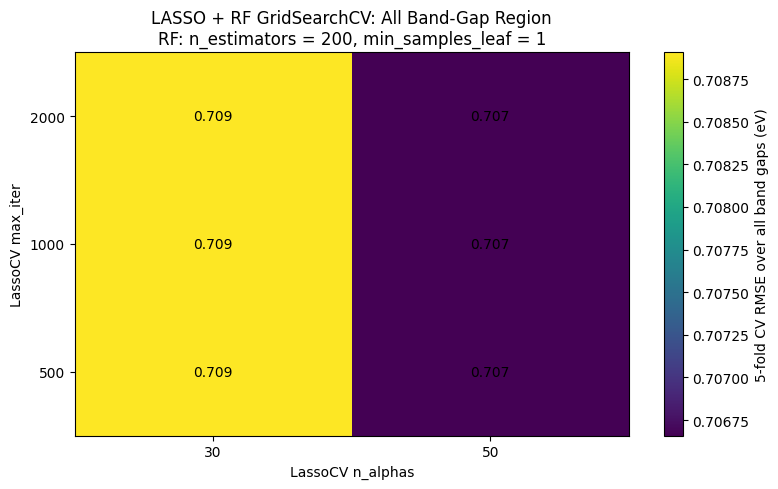

In [ ]:
# ============================================================
# Heatmap: LASSO + RF CV RMSE over all band gaps
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

heatmap_lasso_all = lasso_rf_grid_results_df.pivot(
    index="max_iter",
    columns="n_alphas",
    values="mean_all_RMSE"
)

display(heatmap_lasso_all)

plt.figure(figsize=(8, 5))

plt.imshow(
    heatmap_lasso_all,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="5-fold CV RMSE over all band gaps (eV)")

plt.xticks(
    ticks=np.arange(len(heatmap_lasso_all.columns)),
    labels=heatmap_lasso_all.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_lasso_all.index)),
    labels=heatmap_lasso_all.index
)

plt.xlabel("LassoCV n_alphas")
plt.ylabel("LassoCV max_iter")
plt.title(
    "LASSO + RF GridSearchCV: All Band-Gap Region\n"
    "RF: n_estimators = 200, min_samples_leaf = 1"
)

for i in range(len(heatmap_lasso_all.index)):
    for j in range(len(heatmap_lasso_all.columns)):
        value = heatmap_lasso_all.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


n_alphas,30,50
max_iter,,
500,0.500735,0.500722
1000,0.500735,0.500722
2000,0.500735,0.500722


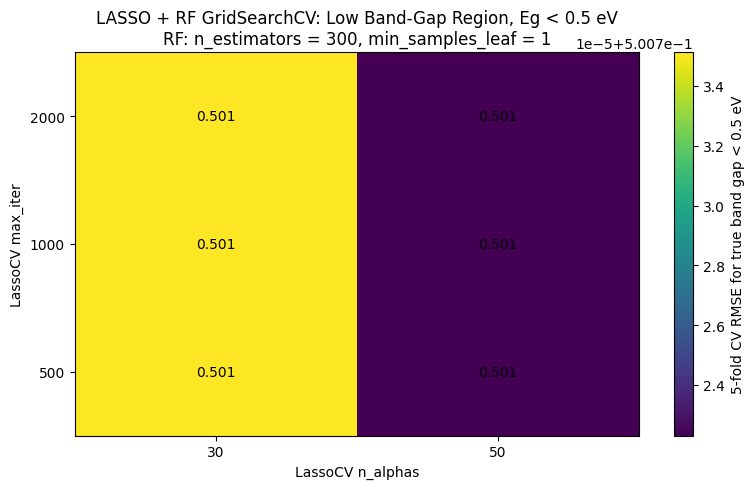

In [ ]:
# ============================================================
# Heatmap: LASSO + RF CV RMSE for true band gap < 0.5 eV
# ============================================================

heatmap_lasso_low = lasso_rf_grid_results_df.pivot(
    index="max_iter",
    columns="n_alphas",
    values="mean_low_gap_RMSE"
)

display(heatmap_lasso_low)

plt.figure(figsize=(8, 5))

plt.imshow(
    heatmap_lasso_low,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="5-fold CV RMSE for true band gap < 0.5 eV")

plt.xticks(
    ticks=np.arange(len(heatmap_lasso_low.columns)),
    labels=heatmap_lasso_low.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_lasso_low.index)),
    labels=heatmap_lasso_low.index
)

plt.xlabel("LassoCV n_alphas")
plt.ylabel("LassoCV max_iter")
plt.title(
    "LASSO + RF GridSearchCV: Low Band-Gap Region, Eg < 0.5 eV\n"
    "RF: n_estimators = 300, min_samples_leaf = 1"
)

for i in range(len(heatmap_lasso_low.index)):
    for j in range(len(heatmap_lasso_low.columns)):
        value = heatmap_lasso_low.iloc[i, j]

        if np.isnan(value):
            text = "NaN"
        else:
            text = f"{value:.3f}"

        plt.text(
            j,
            i,
            text,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Best LASSO + RF settings from CV
# ============================================================

best_lasso_all = lasso_rf_grid_results_df.sort_values("mean_all_RMSE").iloc[0]
best_lasso_low = lasso_rf_grid_results_df.sort_values("mean_low_gap_RMSE").iloc[0]

print("Best LASSO + RF setting for GENERAL band-gap RMSE:")
print("n_alphas:", int(best_lasso_all["n_alphas"]))
print("max_iter:", int(best_lasso_all["max_iter"]))
print("Mean all-gap CV RMSE:", best_lasso_all["mean_all_RMSE"], "eV")
print("Mean low-gap CV RMSE at this setting:", best_lasso_all["mean_low_gap_RMSE"], "eV")
print("Mean selected features:", best_lasso_all["mean_selected_features"])
print("Mean LASSO alpha:", best_lasso_all["mean_lasso_alpha"])

print("\nBest LASSO + RF setting for LOW band-gap RMSE, Eg < 0.5 eV:")
print("n_alphas:", int(best_lasso_low["n_alphas"]))
print("max_iter:", int(best_lasso_low["max_iter"]))
print("Mean low-gap CV RMSE:", best_lasso_low["mean_low_gap_RMSE"], "eV")
print("Mean all-gap CV RMSE at this setting:", best_lasso_low["mean_all_RMSE"], "eV")
print("Mean selected features:", best_lasso_low["mean_selected_features"])
print("Mean LASSO alpha:", best_lasso_low["mean_lasso_alpha"])


Best LASSO + RF setting for GENERAL band-gap RMSE:
n_alphas: 50
max_iter: 500
Mean all-gap CV RMSE: 0.706658686066019 eV
Mean low-gap CV RMSE at this setting: 0.5007223074806839 eV
Mean selected features: 58.0
Mean LASSO alpha: 0.004797001247954036

Best LASSO + RF setting for LOW band-gap RMSE, Eg < 0.5 eV:
n_alphas: 50
max_iter: 500
Mean low-gap CV RMSE: 0.5007223074806839 eV
Mean all-gap CV RMSE at this setting: 0.706658686066019 eV
Mean selected features: 58.0
Mean LASSO alpha: 0.004797001247954036


In [ ]:
# ============================================================
# RMSE vs n_estimators at min_samples_leaf = 1
# Metrics:
# 1. General RMSE over all band gaps
# 2. Low-band-gap RMSE where true band_gap < 0.5 eV
# ============================================================

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target_col = "band_gap"
low_gap_cutoff = 0.5

n_estimators_list = [120, 160, 180, 200, 220, 320]
min_leaf = 1

# Define target
y = feature_df[target_col].copy()

# Keep rows with target
valid_idx = y.dropna().index

X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

# Hold out final test set
X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.20,
    random_state=42
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

n_tree_results = []

for n_estimators in n_estimators_list:

    fold_all_rmse = []
    fold_low_rmse = []
    fold_low_counts = []

    for train_idx, val_idx in kf.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Normalize inside each CV fold
        scaler = StandardScaler()

        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler.transform(X_fold_val)

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            min_samples_leaf=min_leaf,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_fold_train_scaled, y_fold_train)

        y_val_pred = rf.predict(X_fold_val_scaled)

        # RMSE over all validation band gaps
        rmse_all = np.sqrt(
            mean_squared_error(y_fold_val, y_val_pred)
        )

        fold_all_rmse.append(rmse_all)

        # RMSE only where true band gap < 0.5 eV
        low_mask = y_fold_val < low_gap_cutoff
        low_count = low_mask.sum()
        fold_low_counts.append(low_count)

        if low_count > 0:
            rmse_low = np.sqrt(
                mean_squared_error(
                    y_fold_val[low_mask],
                    y_val_pred[low_mask]
                )
            )
        else:
            rmse_low = np.nan

        fold_low_rmse.append(rmse_low)

    n_tree_results.append({
        "n_estimators": n_estimators,
        "min_samples_leaf": min_leaf,

        "mean_all_RMSE": np.mean(fold_all_rmse),
        "std_all_RMSE": np.std(fold_all_rmse),

        "mean_low_gap_RMSE": np.nanmean(fold_low_rmse),
        "std_low_gap_RMSE": np.nanstd(fold_low_rmse),

        "total_low_gap_val_count": np.sum(fold_low_counts),
        "fold_low_gap_counts": fold_low_counts,
    })

n_tree_results_df = pd.DataFrame(n_tree_results)

display(n_tree_results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unno

,n_estimators,min_samples_leaf,mean_all_RMSE,std_all_RMSE,mean_low_gap_RMSE,std_low_gap_RMSE,total_low_gap_val_count,fold_low_gap_counts
0,120,1,0.720522,0.038734,0.544481,0.094598,932,"[188, 175, 184, 195, 190]"
1,160,1,0.719370,0.042443,0.541772,0.094725,932,"[188, 175, 184, 195, 190]"
2,180,1,0.719451,0.042781,0.542323,0.094719,932,"[188, 175, 184, 195, 190]"
3,200,1,0.719362,0.043238,0.542861,0.092240,932,"[188, 175, 184, 195, 190]"
4,220,1,0.717907,0.043834,0.540783,0.093566,932,"[188, 175, 184, 195, 190]"
5,320,1,0.718682,0.047194,0.542635,0.096137,932,"[188, 175, 184, 195, 190]"


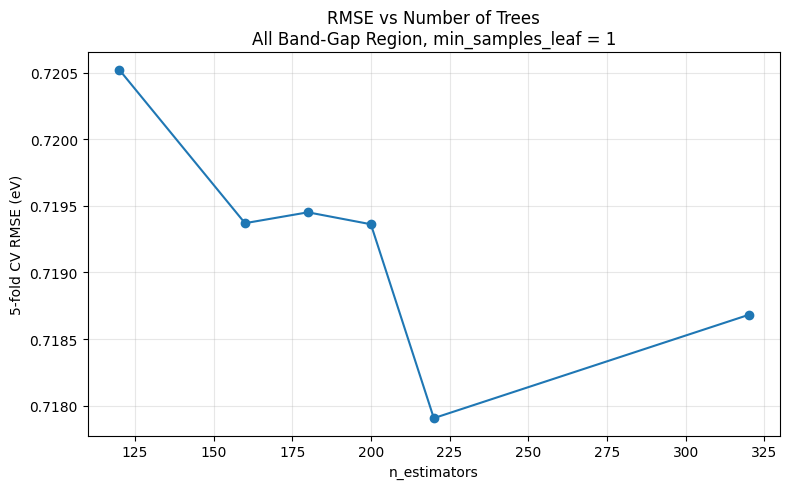

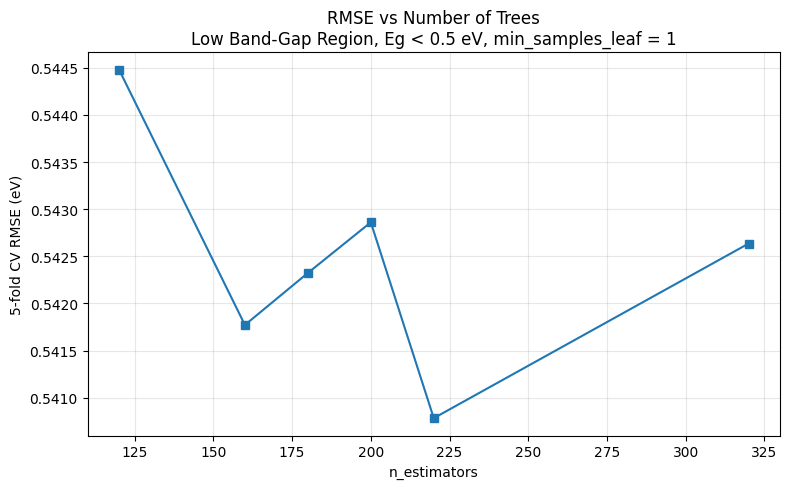

In [ ]:
# ============================================================
# Separate plots
# ============================================================

# All band gaps
plt.figure(figsize=(8, 5))

plt.plot(
    n_tree_results_df["n_estimators"],
    n_tree_results_df["mean_all_RMSE"],
    marker="o"
)

plt.xlabel("n_estimators")
plt.ylabel("5-fold CV RMSE (eV)")
plt.title("RMSE vs Number of Trees\nAll Band-Gap Region, min_samples_leaf = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Low band gaps
plt.figure(figsize=(8, 5))

plt.plot(
    n_tree_results_df["n_estimators"],
    n_tree_results_df["mean_low_gap_RMSE"],
    marker="s"
)

plt.xlabel("n_estimators")
plt.ylabel("5-fold CV RMSE (eV)")
plt.title("RMSE vs Number of Trees\nLow Band-Gap Region, Eg < 0.5 eV, min_samples_leaf = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Compare feature strategies before Random Forest
# 1. No selection
# 2. LASSO-selected features
# 3. PCA features
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Target
# -----------------------------

target_col = "band_gap"
low_gap_cutoff = 0.5

y = feature_df[target_col].copy()

valid_idx = y.dropna().index

X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

# -----------------------------
# Train/test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.20,
    random_state=42
)

# -----------------------------
# Normalize features
# -----------------------------

scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (1375, 155)
X_test_scaled: (344, 155)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
# ============================================================
# Helper function for model evaluation
# ============================================================

def evaluate_predictions(y_true, y_pred, low_gap_cutoff=0.5):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    low_mask = y_true < low_gap_cutoff

    if low_mask.sum() > 0:
        low_rmse = np.sqrt(
            mean_squared_error(
                y_true[low_mask],
                y_pred[low_mask]
            )
        )
    else:
        low_rmse = np.nan

    return {
        "MAE": mae,
        "RMSE_all": rmse,
        "R2": r2,
        "RMSE_low_gap": low_rmse,
        "low_gap_test_count": int(low_mask.sum())
    }


def train_rf_and_eval(X_train_input, X_test_input, model_name):
    rf = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_input, y_train)

    y_pred = rf.predict(X_test_input)

    metrics = evaluate_predictions(
        y_test,
        y_pred,
        low_gap_cutoff=low_gap_cutoff
    )

    print(model_name)
    print(metrics)

    return rf, y_pred, metrics

In [ ]:
# ============================================================
# Model 1 — RF with all features, no feature selection
# ============================================================

rf_all, y_pred_all, metrics_all = train_rf_and_eval(
    X_train_scaled,
    X_test_scaled,
    model_name="RF with all features"
)

RF with all features
{'MAE': 0.4093938135915583, 'RMSE_all': np.float64(0.6700822707211943), 'R2': 0.821118135952404, 'RMSE_low_gap': np.float64(0.46050917346150766), 'low_gap_test_count': 233}


In [ ]:
# ============================================================
# Model 2 — LASSO feature selection, then RF
# Fixed: drops all-NaN columns before imputation
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Remove columns that are completely NaN in training set
# ------------------------------------------------------------

all_nan_cols = X_train.columns[X_train.isna().all()].tolist()

print("All-NaN columns removed before LASSO:")
print(all_nan_cols)

X_train_clean = X_train.drop(columns=all_nan_cols).copy()
X_test_clean = X_test.drop(columns=all_nan_cols).copy()

# Replace inf with NaN just in case
X_train_clean = X_train_clean.replace([np.inf, -np.inf], np.nan)
X_test_clean = X_test_clean.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Impute missing values using training-set median only
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

# ------------------------------------------------------------
# Scale after imputation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

# ------------------------------------------------------------
# LASSO feature selection
# ------------------------------------------------------------

lasso = LassoCV(
    cv=5,
    n_alphas=50,
    max_iter=10000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

lasso_coef = pd.Series(
    lasso.coef_,
    index=X_train_scaled.columns
)

selected_features = lasso_coef[lasso_coef != 0].index.tolist()

print("Best LASSO alpha:", lasso.alpha_)
print("Original number of features:", X_train.shape[1])
print("Features after removing all-NaN columns:", X_train_scaled.shape[1])
print("Number of LASSO-selected features:", len(selected_features))

# Fallback if LASSO is too aggressive
if len(selected_features) == 0:
    print("LASSO selected zero features. Using top 20 absolute coefficients instead.")
    selected_features = (
        lasso_coef.abs()
        .sort_values(ascending=False)
        .head(20)
        .index
        .tolist()
    )

print("Final selected features:", len(selected_features))

display(
    pd.DataFrame({
        "selected_feature": selected_features,
        "lasso_coef": lasso_coef[selected_features].values
    }).sort_values("lasso_coef", key=abs, ascending=False)
)

# ------------------------------------------------------------
# Train RF using only LASSO-selected features
# ------------------------------------------------------------

X_train_lasso = X_train_scaled[selected_features].copy()
X_test_lasso = X_test_scaled[selected_features].copy()

rf_lasso, y_pred_lasso, metrics_lasso = train_rf_and_eval(
    X_train_lasso,
    X_test_lasso,
    model_name="LASSO-selected features → RF"
)

All-NaN columns removed before LASSO:
['X_like_coefficient_of_linear_thermal_expansion']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.9342473602441714, tolerance: 2.2683023779055507
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.984556851401294, tolerance: 2.2224971166443175
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.014807751685112, tolerance: 2.2224971166443175
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergenc

Best LASSO alpha: 0.004472784572760462
Original number of features: 155
Features after removing all-NaN columns: 154
Number of LASSO-selected features: 57
Final selected features: 57


,selected_feature,lasso_coef
50,range_ox_mean_ABX3,-0.812963
24,B_like_d_electrons,-0.704873
26,X_like_group,0.684881
47,std_ox_max_ABX3,0.509076
42,std_p_electrons_ABX3,0.496497
23,B_like_p_electrons,0.435568
41,range_s_electrons_ABX3,-0.406313
15,B_like_density_of_solid,-0.357892
30,range_row_ABX3,0.342871
49,std_ox_mean_ABX3,0.317812


LASSO-selected features → RF
{'MAE': 0.40497113864058476, 'RMSE_all': np.float64(0.6415200516480102), 'R2': 0.836042786801916, 'RMSE_low_gap': np.float64(0.4453500364517926), 'low_gap_test_count': 233}


In [ ]:
# ============================================================
# Model 3 — PCA features, then RF
# ============================================================

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance retained:", pca.explained_variance_ratio_.sum())

rf_pca, y_pred_pca, metrics_pca = train_rf_and_eval(
    X_train_pca,
    X_test_pca,
    model_name="PCA features → RF"
)

Original number of features: 154
Number of PCA components: 23
Explained variance retained: 0.954306132945919
PCA features → RF
{'MAE': 0.6690954140917849, 'RMSE_all': np.float64(0.9699491398557303), 'R2': 0.6251927512076636, 'RMSE_low_gap': np.float64(0.5875760337401505), 'low_gap_test_count': 233}


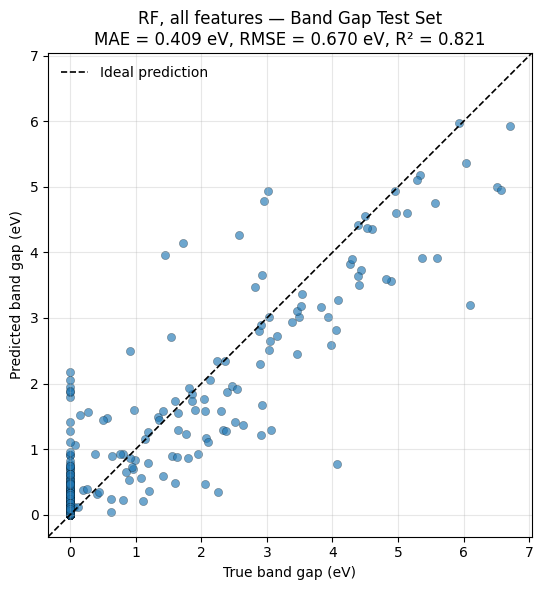

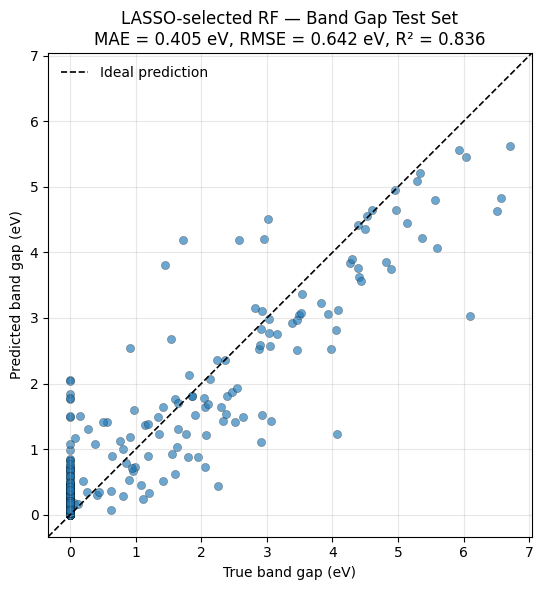

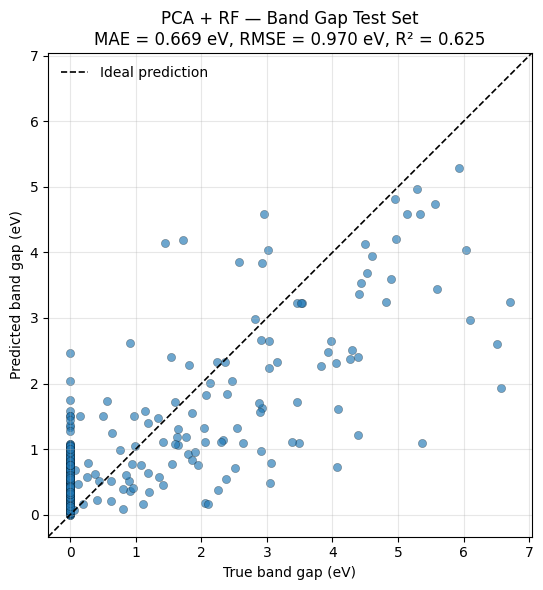

In [ ]:
# ============================================================
# Predicted vs true plots for all three methods
# MAE, RMSE, R2 only
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

predictions = {
    "RF, all features": y_pred_all,
    "LASSO-selected RF": y_pred_lasso,
    "PCA + RF": y_pred_pca
}

for model_name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.25
    )

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    pad = 0.05 * (max_val - min_val)

    lower = min_val - pad
    upper = max_val + pad

    plt.plot(
        [lower, upper],
        [lower, upper],
        "k--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("True band gap (eV)")
    plt.ylabel("Predicted band gap (eV)")

    plt.title(
        f"{model_name} — Band Gap Test Set\n"
        f"MAE = {mae:.3f} eV, "
        f"RMSE = {rmse:.3f} eV, "
        f"R² = {r2:.3f}"
    )

    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


All-NaN hull columns removed:
['X_like_coefficient_of_linear_thermal_expansion']
Hull LASSO alpha: 0.003501146645037362
Hull LASSO-selected features: 42
Hull PCA components: 23


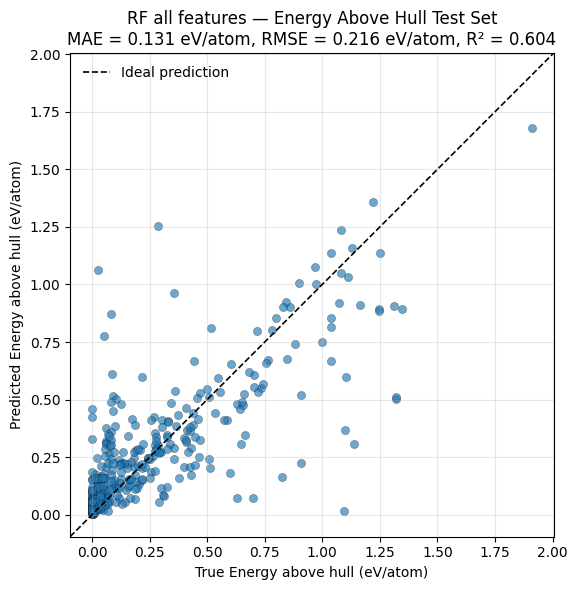

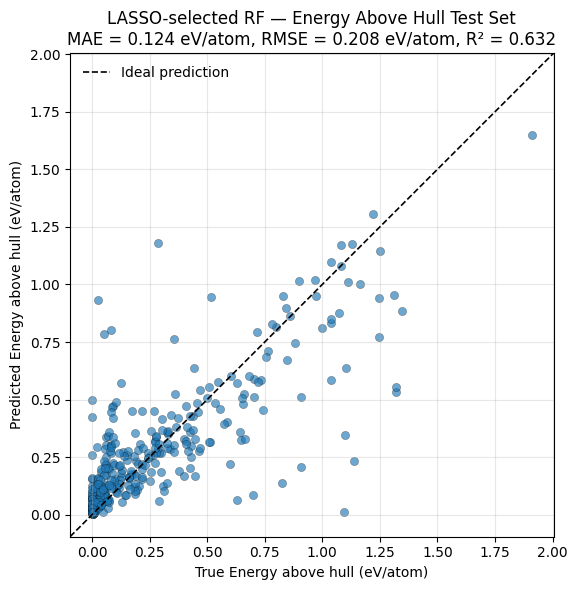

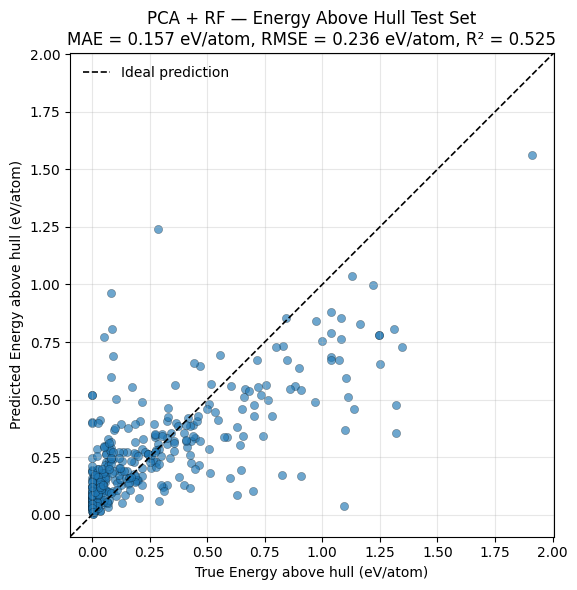

In [ ]:
# ============================================================
# Energy above hull — Test-set parity plots
# RF all features, LASSO-selected RF, PCA + RF
# Self-contained version
# MAE, RMSE, R2 only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Target = energy above hull
# ------------------------------------------------------------

target_col_hull = "energy_above_hull"
unit_hull = "eV/atom"
axis_label_hull = "Energy above hull (eV/atom)"

y_hull = feature_df[target_col_hull].copy()
valid_idx_hull = y_hull.dropna().index

X_hull = X.loc[valid_idx_hull].copy()
y_hull = y_hull.loc[valid_idx_hull].copy()

X_hull = X_hull.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X_train_hull, X_test_hull, y_train_hull, y_test_hull = train_test_split(
    X_hull,
    y_hull,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Drop all-NaN columns based on training set
# ------------------------------------------------------------

all_nan_cols_hull = X_train_hull.columns[X_train_hull.isna().all()].tolist()

print("All-NaN hull columns removed:")
print(all_nan_cols_hull)

X_train_hull_clean = X_train_hull.drop(columns=all_nan_cols_hull).copy()
X_test_hull_clean = X_test_hull.drop(columns=all_nan_cols_hull).copy()

# ------------------------------------------------------------
# Impute missing values
# ------------------------------------------------------------

imputer_hull = SimpleImputer(strategy="median")

X_train_hull_imputed = pd.DataFrame(
    imputer_hull.fit_transform(X_train_hull_clean),
    columns=X_train_hull_clean.columns,
    index=X_train_hull_clean.index
)

X_test_hull_imputed = pd.DataFrame(
    imputer_hull.transform(X_test_hull_clean),
    columns=X_test_hull_clean.columns,
    index=X_test_hull_clean.index
)

# ------------------------------------------------------------
# Scale
# ------------------------------------------------------------

scaler_hull = StandardScaler()

X_train_hull_scaled = pd.DataFrame(
    scaler_hull.fit_transform(X_train_hull_imputed),
    columns=X_train_hull_imputed.columns,
    index=X_train_hull_imputed.index
)

X_test_hull_scaled = pd.DataFrame(
    scaler_hull.transform(X_test_hull_imputed),
    columns=X_test_hull_imputed.columns,
    index=X_test_hull_imputed.index
)

# ============================================================
# 1. RF all features
# ============================================================

rf_hull_all = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_hull_all.fit(X_train_hull_scaled, y_train_hull)
y_pred_hull_all = rf_hull_all.predict(X_test_hull_scaled)

# ============================================================
# 2. LASSO-selected RF
# ============================================================

lasso_hull = LassoCV(
    cv=5,
    n_alphas=50,
    max_iter=10000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

lasso_hull.fit(X_train_hull_scaled, y_train_hull)

lasso_coef_hull = pd.Series(
    lasso_hull.coef_,
    index=X_train_hull_scaled.columns
)

selected_features_hull = lasso_coef_hull[lasso_coef_hull != 0].index.tolist()

if len(selected_features_hull) == 0:
    selected_features_hull = (
        lasso_coef_hull.abs()
        .sort_values(ascending=False)
        .head(20)
        .index
        .tolist()
    )

print("Hull LASSO alpha:", lasso_hull.alpha_)
print("Hull LASSO-selected features:", len(selected_features_hull))

rf_hull_lasso = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_hull_lasso.fit(
    X_train_hull_scaled[selected_features_hull],
    y_train_hull
)

y_pred_hull_lasso = rf_hull_lasso.predict(
    X_test_hull_scaled[selected_features_hull]
)

# ============================================================
# 3. PCA + RF
# ============================================================

pca_hull = PCA(
    n_components=0.95,
    random_state=42
)

X_train_hull_pca = pca_hull.fit_transform(X_train_hull_scaled)
X_test_hull_pca = pca_hull.transform(X_test_hull_scaled)

rf_hull_pca = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_hull_pca.fit(X_train_hull_pca, y_train_hull)
y_pred_hull_pca = rf_hull_pca.predict(X_test_hull_pca)

print("Hull PCA components:", X_train_hull_pca.shape[1])

# ============================================================
# Plot parity plots
# ============================================================

hull_predictions = {
    "RF all features": y_pred_hull_all,
    "LASSO-selected RF": y_pred_hull_lasso,
    "PCA + RF": y_pred_hull_pca
}

for model_name, y_pred in hull_predictions.items():

    mae = mean_absolute_error(y_test_hull, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_hull, y_pred))
    r2 = r2_score(y_test_hull, y_pred)

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_hull,
        y_pred,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.25
    )

    min_val = min(y_test_hull.min(), y_pred.min())
    max_val = max(y_test_hull.max(), y_pred.max())
    pad = 0.05 * (max_val - min_val)

    lower = min_val - pad
    upper = max_val + pad

    plt.plot(
        [lower, upper],
        [lower, upper],
        "k--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"True {axis_label_hull}")
    plt.ylabel(f"Predicted {axis_label_hull}")

    plt.title(
        f"{model_name} — Energy Above Hull Test Set\n"
        f"MAE = {mae:.3f} {unit_hull}, "
        f"RMSE = {rmse:.3f} {unit_hull}, "
        f"R² = {r2:.3f}"
    )

    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

## Prediction

In [ ]:
# ============================================================
# Install pymatgen if missing
# ============================================================

!pip install -q pymatgen

from pymatgen.core import Element, Composition

print("pymatgen imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency con

In [ ]:
# ============================================================
# Generate all possible ABX3 candidates from seen A/B/X elements
# Optional charge-balance filter
# ============================================================

import itertools
import numpy as np
import pandas as pd
from pymatgen.core import Element, Composition

# Pull A/B/X element pools from your actual feature dataset
A_candidates = sorted(feature_df["A_like"].dropna().unique().tolist())
B_candidates = sorted(feature_df["B_like"].dropna().unique().tolist())
halides = ["F", "Cl", "Br", "I", "O", "S"]

A_candidates = sorted(feature_df["A_like"].dropna().unique().tolist())
B_candidates = sorted(feature_df["B_like"].dropna().unique().tolist())

X_candidates = sorted(
    [x for x in feature_df["X_like"].dropna().unique().tolist() if x in halides]
)

print("Number of seen A_like elements:", len(A_candidates))
print(A_candidates)

print("\nNumber of seen B_like elements:", len(B_candidates))
print(B_candidates)

print("\nNumber of seen X_like elements:", len(X_candidates))
print(X_candidates)

print("\nTotal possible ABX3 combinations before filtering:")
print(len(A_candidates) * len(B_candidates) * len(X_candidates))

Number of seen A_like elements: 69
['Ac', 'Ag', 'Al', 'Au', 'Ba', 'Be', 'Bi', 'Ca', 'Cd', 'Ce', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Sb', 'Sc', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']

Number of seen B_like elements: 77
['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']

Number of seen X_like elements: 6
['Br', 'Cl', 'F', 'I', 'O', 'S']

In [ ]:
# ============================================================
# Charge-balance helper for ABX3
# ============================================================

def get_possible_oxidation_states(symbol):
    """
    Get common oxidation states first.
    If unavailable, fall back to all oxidation states.
    """
    el = Element(symbol)

    ox_states = list(el.common_oxidation_states)

    if len(ox_states) == 0:
        ox_states = list(el.oxidation_states)

    return [int(x) for x in ox_states]


def find_charge_balanced_states(A, B, X):
    """
    Return all oxidation-state combinations satisfying:
        q_A + q_B + 3*q_X = 0
    """

    A_ox = get_possible_oxidation_states(A)
    B_ox = get_possible_oxidation_states(B)
    X_ox = get_possible_oxidation_states(X)

    balanced_states = []

    for qA, qB, qX in itertools.product(A_ox, B_ox, X_ox):
        if qA + qB + 3 * qX == 0:
            balanced_states.append((qA, qB, qX))

    return balanced_states

In [ ]:
# ============================================================
# Candidate feature-generation functions
# Needed before generating hypothetical ABX3 candidates
# ============================================================

!pip install -q pymatgen

import numpy as np
import pandas as pd
from pymatgen.core import Element

def safe_float(value):
    try:
        if value is None:
            return np.nan
        return float(value)
    except Exception:
        return np.nan


def safe_prop(symbol, prop):
    try:
        value = getattr(Element(symbol), prop)
        return safe_float(value)
    except Exception:
        return np.nan


def safe_div(a, b):
    try:
        if pd.isna(a) or pd.isna(b) or b == 0:
            return np.nan
        return a / b
    except Exception:
        return np.nan


def oxidation_features(el):
    ox_states = list(el.common_oxidation_states)

    if len(ox_states) == 0:
        ox_states = list(el.oxidation_states)

    if len(ox_states) == 0:
        return {
            "ox_min": np.nan,
            "ox_max": np.nan,
            "ox_mean": np.nan,
            "ox_range": np.nan,
            "ox_count": 0,
        }

    ox_states = np.array(ox_states, dtype=float)

    return {
        "ox_min": np.min(ox_states),
        "ox_max": np.max(ox_states),
        "ox_mean": np.mean(ox_states),
        "ox_range": np.max(ox_states) - np.min(ox_states),
        "ox_count": len(ox_states),
    }


def orbital_electron_counts(el):
    counts = {
        "s_electrons": 0.0,
        "p_electrons": 0.0,
        "d_electrons": 0.0,
        "f_electrons": 0.0,
    }

    try:
        for n, orbital, electrons in el.full_electronic_structure:
            key = f"{orbital}_electrons"
            if key in counts:
                counts[key] += float(electrons)
    except Exception:
        pass

    counts["total_electrons_from_config"] = (
        counts["s_electrons"]
        + counts["p_electrons"]
        + counts["d_electrons"]
        + counts["f_electrons"]
    )

    return counts


def site_element_features(prefix, symbol):
    el = Element(symbol)

    features = {
        f"{prefix}_Z": el.Z,
        f"{prefix}_mass": safe_float(el.atomic_mass),
        f"{prefix}_en": safe_prop(symbol, "X"),

        f"{prefix}_row": el.row,
        f"{prefix}_group": el.group,
        f"{prefix}_mendeleev": el.mendeleev_no,

        f"{prefix}_atomic_radius": safe_prop(symbol, "atomic_radius"),
        f"{prefix}_atomic_radius_calculated": safe_prop(symbol, "atomic_radius_calculated"),
        f"{prefix}_van_der_waals_radius": safe_prop(symbol, "van_der_waals_radius"),

        f"{prefix}_melting_point": safe_prop(symbol, "melting_point"),
        f"{prefix}_boiling_point": safe_prop(symbol, "boiling_point"),
        f"{prefix}_density_of_solid": safe_prop(symbol, "density_of_solid"),

        f"{prefix}_thermal_conductivity": safe_prop(symbol, "thermal_conductivity"),
        f"{prefix}_electrical_resistivity": safe_prop(symbol, "electrical_resistivity"),
        f"{prefix}_coefficient_of_linear_thermal_expansion": safe_prop(
            symbol,
            "coefficient_of_linear_thermal_expansion"
        ),
    }

    ox = oxidation_features(el)
    for k, v in ox.items():
        features[f"{prefix}_{k}"] = v

    orb = orbital_electron_counts(el)
    for k, v in orb.items():
        features[f"{prefix}_{k}"] = v

    return features


def weighted_mean(values, weights):
    values = np.array(values, dtype=float)
    weights = np.array(weights, dtype=float)

    mask = ~np.isnan(values)

    if mask.sum() == 0:
        return np.nan

    return np.average(values[mask], weights=weights[mask])


def weighted_std(values, weights):
    values = np.array(values, dtype=float)
    weights = np.array(weights, dtype=float)

    mask = ~np.isnan(values)

    if mask.sum() == 0:
        return np.nan

    avg = np.average(values[mask], weights=weights[mask])

    return np.sqrt(
        np.average((values[mask] - avg) ** 2, weights=weights[mask])
    )


def range_ignore_nan(values):
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan

    return np.max(values) - np.min(values)


def make_general_abx3_features(A_like, B_like, X_like):
    features = {}

    features.update(site_element_features("A_like", A_like))
    features.update(site_element_features("B_like", B_like))
    features.update(site_element_features("X_like", X_like))

    weights = np.array([1, 1, 3], dtype=float)

    aggregate_props = [
        "Z",
        "mass",
        "en",
        "row",
        "group",
        "mendeleev",
        "atomic_radius",
        "atomic_radius_calculated",
        "van_der_waals_radius",
        "melting_point",
        "boiling_point",
        "density_of_solid",
        "thermal_conductivity",
        "electrical_resistivity",
        "s_electrons",
        "p_electrons",
        "d_electrons",
        "f_electrons",
        "ox_min",
        "ox_max",
        "ox_mean",
        "ox_range",
    ]

    for prop in aggregate_props:
        vals = [
            features.get(f"A_like_{prop}", np.nan),
            features.get(f"B_like_{prop}", np.nan),
            features.get(f"X_like_{prop}", np.nan),
        ]

        features[f"mean_{prop}_ABX3"] = weighted_mean(vals, weights)
        features[f"std_{prop}_ABX3"] = weighted_std(vals, weights)
        features[f"range_{prop}_ABX3"] = range_ignore_nan(vals)

    features["B_minus_X_en"] = features["B_like_en"] - features["X_like_en"]
    features["A_minus_X_en"] = features["A_like_en"] - features["X_like_en"]
    features["A_minus_B_en"] = features["A_like_en"] - features["B_like_en"]

    features["abs_B_minus_X_en"] = abs(features["B_minus_X_en"])
    features["abs_A_minus_X_en"] = abs(features["A_minus_X_en"])
    features["abs_A_minus_B_en"] = abs(features["A_minus_B_en"])

    features["B_over_X_atomic_radius"] = safe_div(
        features["B_like_atomic_radius"],
        features["X_like_atomic_radius"]
    )

    features["A_over_X_atomic_radius"] = safe_div(
        features["A_like_atomic_radius"],
        features["X_like_atomic_radius"]
    )

    features["A_over_B_atomic_radius"] = safe_div(
        features["A_like_atomic_radius"],
        features["B_like_atomic_radius"]
    )

    rA = features["A_like_atomic_radius"]
    rB = features["B_like_atomic_radius"]
    rX = features["X_like_atomic_radius"]

    features["radius_tolerance_proxy"] = safe_div(
        rA + rX,
        np.sqrt(2) * (rB + rX)
    )

    features["octahedral_radius_proxy"] = safe_div(
        rB,
        rX
    )

    rA_calc = features["A_like_atomic_radius_calculated"]
    rB_calc = features["B_like_atomic_radius_calculated"]
    rX_calc = features["X_like_atomic_radius_calculated"]

    features["calc_radius_tolerance_proxy"] = safe_div(
        rA_calc + rX_calc,
        np.sqrt(2) * (rB_calc + rX_calc)
    )

    features["calc_octahedral_radius_proxy"] = safe_div(
        rB_calc,
        rX_calc
    )

    return features

print("Feature-generation function is ready.")

Feature-generation function is ready.


In [ ]:
# ============================================================
# Generate charge-balanced ABX3 candidates from seen A/B/X pools
# Halide X-site only
# Charge balance happens BEFORE feature generation
# ============================================================

import itertools
import numpy as np
import pandas as pd
from pymatgen.core import Element

# A and B from seen data
A_candidates = sorted(feature_df["A_like"].dropna().unique().tolist())
B_candidates = sorted(feature_df["B_like"].dropna().unique().tolist())

# X-site restricted to halides only
halides = ["F", "Cl", "Br", "I", "O"]

X_candidates = sorted(
    [x for x in feature_df["X_like"].dropna().unique().tolist() if x in halides]
)

print("A candidates:", len(A_candidates), A_candidates)
print("B candidates:", len(B_candidates), B_candidates)
print("Halide X candidates:", len(X_candidates), X_candidates)

total_raw = len(A_candidates) * len(B_candidates) * len(X_candidates)
print("Total raw ABX3 combinations before charge balance:", total_raw)

A candidates: 69 ['Ac', 'Ag', 'Al', 'Au', 'Ba', 'Be', 'Bi', 'Ca', 'Cd', 'Ce', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Sb', 'Sc', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']
B candidates: 77 ['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']
Halide X candidates: 5 ['Br', 'Cl', 'F', 'I', 'O']
Total raw ABX3 combinations before charge balance: 26

## Simpe RF

### Lasso +  RF

In [ ]:
# ============================================================
# Train final discovery models on full dataset
# LASSO-selected features + RF
# band_gap model + energy_above_hull model
# Fixed: removes all-NaN columns, imputes missing values, then scales
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd

target_cols = ["band_gap", "energy_above_hull"]

valid_idx = feature_df.dropna(subset=target_cols).index

X_full = X.loc[valid_idx].copy()
y_bandgap_full = feature_df.loc[valid_idx, "band_gap"].copy()
y_hull_full = feature_df.loc[valid_idx, "energy_above_hull"].copy()

# Replace inf with NaN
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Drop columns that are completely NaN
# ------------------------------------------------------------

final_all_nan_cols = X_full.columns[X_full.isna().all()].tolist()

print("All-NaN columns removed before final discovery training:")
print(final_all_nan_cols)

X_full_clean = X_full.drop(columns=final_all_nan_cols).copy()

# ------------------------------------------------------------
# Impute missing values using full training median
# ------------------------------------------------------------

final_imputer = SimpleImputer(strategy="median")

X_full_imputed = pd.DataFrame(
    final_imputer.fit_transform(X_full_clean),
    columns=X_full_clean.columns,
    index=X_full_clean.index
)

# ------------------------------------------------------------
# Scale full feature matrix
# ------------------------------------------------------------

final_scaler = StandardScaler()

X_full_scaled_array = final_scaler.fit_transform(X_full_imputed)

X_full_scaled = pd.DataFrame(
    X_full_scaled_array,
    columns=X_full_imputed.columns,
    index=X_full_imputed.index
)

# ------------------------------------------------------------
# LASSO feature selector helper
# ------------------------------------------------------------

def select_lasso_features(X_scaled, y, target_name):
    lasso = LassoCV(
        cv=5,
        n_alphas=50,
        max_iter=10000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    )

    lasso.fit(X_scaled, y)

    lasso_coef = pd.Series(
        lasso.coef_,
        index=X_scaled.columns
    )

    selected_features = lasso_coef[lasso_coef != 0].index.tolist()

    # fallback if LASSO is too aggressive
    if len(selected_features) == 0:
        selected_features = (
            lasso_coef.abs()
            .sort_values(ascending=False)
            .head(20)
            .index
            .tolist()
        )

    print(f"\n{target_name} LASSO selection")
    print("Chosen alpha:", lasso.alpha_)
    print("Selected features:", len(selected_features))

    display(
        pd.DataFrame({
            "feature": selected_features,
            "lasso_coef": lasso_coef[selected_features].values
        }).sort_values("lasso_coef", key=abs, ascending=False)
    )

    return lasso, selected_features

# ------------------------------------------------------------
# Select features separately for band gap and hull
# ------------------------------------------------------------

lasso_bandgap_model, selected_features_bandgap = select_lasso_features(
    X_full_scaled,
    y_bandgap_full,
    "Band gap"
)

lasso_hull_model, selected_features_hull = select_lasso_features(
    X_full_scaled,
    y_hull_full,
    "Energy above hull"
)

# ------------------------------------------------------------
# Train RF models using LASSO-selected features
# ------------------------------------------------------------

final_n_estimators = 200
final_min_samples_leaf = 1

final_bandgap_model = RandomForestRegressor(
    n_estimators=final_n_estimators,
    min_samples_leaf=final_min_samples_leaf,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_hull_model = RandomForestRegressor(
    n_estimators=final_n_estimators,
    min_samples_leaf=final_min_samples_leaf,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_bandgap_model.fit(
    X_full_scaled[selected_features_bandgap],
    y_bandgap_full
)

final_hull_model.fit(
    X_full_scaled[selected_features_hull],
    y_hull_full
)

print("\nFinal LASSO + RF discovery models trained.")
print("Training samples:", X_full.shape[0])
print("Original number of features:", X_full.shape[1])
print("Features after removing all-NaN columns:", X_full_scaled.shape[1])
print("Band gap selected features:", len(selected_features_bandgap))
print("Hull selected features:", len(selected_features_hull))

All-NaN columns removed before final discovery training:
['X_like_coefficient_of_linear_thermal_expansion']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.5375537374495707, tolerance: 3.363600425404541
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.295831432601972, tolerance: 3.128120798705452
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.844257536739406, tolerance: 3.363600425404541
  model = cd_fast.enet_coordinate_descent_gram(



Band gap LASSO selection
Chosen alpha: 0.0030983471735912013
Selected features: 69


,feature,lasso_coef
63,range_ox_mean_ABX3,-0.917744
29,B_like_d_electrons,-0.731492
31,X_like_group,0.679887
38,std_en_ABX3,0.655355
60,std_ox_max_ABX3,0.579132
...,...,...
11,A_like_coefficient_of_linear_thermal_expansion,0.009787
55,mean_d_electrons_ABX3,-0.008203
35,X_like_ox_min,0.006850
65,range_ox_range_ABX3,-0.002662



Energy above hull LASSO selection
Chosen alpha: 0.0023340640313020246
Selected features: 48


,feature,lasso_coef
0,A_like_atomic_radius,-0.215007
9,B_like_row,-0.202261
18,B_like_d_electrons,0.138491
29,std_van_der_waals_radius_ABX3,0.131932
38,mean_f_electrons_ABX3,0.111449
27,range_mendeleev_ABX3,-0.098331
39,range_f_electrons_ABX3,-0.068655
46,calc_radius_tolerance_proxy,0.066065
13,B_like_van_der_waals_radius,0.060806
45,radius_tolerance_proxy,0.043426



Final LASSO + RF discovery models trained.
Training samples: 1719
Original number of features: 155
Features after removing all-NaN columns: 154
Band gap selected features: 69
Hull selected features: 48


In [ ]:
# ============================================================
# Generate charge-balanced ABX3 candidates from seen A/B/X pools
# Charge balance happens BEFORE feature generation
# Also removes A = B candidates
# ============================================================

import itertools
import numpy as np
import pandas as pd
from pymatgen.core import Element

A_candidates = sorted(feature_df["A_like"].dropna().unique().tolist())
B_candidates = sorted(feature_df["B_like"].dropna().unique().tolist())
X_candidates = sorted(feature_df["X_like"].dropna().unique().tolist())

print("A candidates:", len(A_candidates), A_candidates)
print("B candidates:", len(B_candidates), B_candidates)
print("X candidates:", len(X_candidates), X_candidates)

total_raw = len(A_candidates) * len(B_candidates) * len(X_candidates)
print("Total raw ABX3 combinations before charge balance:", total_raw)


def get_possible_oxidation_states(symbol):
    el = Element(symbol)

    ox_states = list(el.common_oxidation_states)

    if len(ox_states) == 0:
        ox_states = list(el.oxidation_states)

    return [int(x) for x in ox_states]


def find_charge_balanced_states(A, B, X):
    """
    For ABX3:
        qA + qB + 3*qX = 0
    """
    A_ox = get_possible_oxidation_states(A)
    B_ox = get_possible_oxidation_states(B)
    X_ox = get_possible_oxidation_states(X)

    balanced_states = []

    for qA, qB, qX in itertools.product(A_ox, B_ox, X_ox):
        if qA + qB + 3 * qX == 0:
            balanced_states.append((qA, qB, qX))

    return balanced_states


existing_formulas = set(feature_df["formula"].astype(str).tolist())

candidate_base_rows = []
skipped_A_equals_B = 0

for A in A_candidates:
    for B in B_candidates:

        # Remove candidates where A and B are the same element
        if A == B:
            skipped_A_equals_B += len(X_candidates)
            continue

        for X_site in X_candidates:

            balanced_states = find_charge_balanced_states(A, B, X_site)

            if len(balanced_states) == 0:
                continue

            formula = f"{A}{B}{X_site}3"

            candidate_base_rows.append({
                "formula": formula,
                "A_like": A,
                "B_like": B,
                "X_like": X_site,
                "possible_charge_states": balanced_states,
                "already_in_dataset": formula in existing_formulas,
            })

candidate_base_df = pd.DataFrame(candidate_base_rows)

print("Skipped A = B raw combinations:", skipped_A_equals_B)
print("Charge-balanced candidates:", candidate_base_df.shape[0])

display(candidate_base_df.head())

A candidates: 69 ['Ac', 'Ag', 'Al', 'Au', 'Ba', 'Be', 'Bi', 'Ca', 'Cd', 'Ce', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Sb', 'Sc', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']
B candidates: 77 ['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'Pa', 'Pb', 'Pd', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']
X candidates: 6 ['Br', 'Cl', 'F', 'I', 'O', 'S']
Total raw ABX3 combinations before charge balance: 3187

,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset
0,AcAlO3,Ac,Al,O,"[(3, 3, -2)]",True
1,AcAlS3,Ac,Al,S,"[(3, 3, -2)]",False
2,AcAsO3,Ac,As,O,"[(3, 3, -2)]",False
3,AcAsS3,Ac,As,S,"[(3, 3, -2)]",False
4,AcAuO3,Ac,Au,O,"[(3, 3, -2)]",False


In [ ]:
# ============================================================
# Generate features for charge-balanced candidates
# This creates candidate_df
# ============================================================

if "candidate_base_df" not in globals():
    raise NameError(
        "candidate_base_df is not defined. Run the charge-balanced candidate-generation cell first."
    )

if "make_general_abx3_features" not in globals():
    raise NameError(
        "make_general_abx3_features is not defined. Run the feature-generation function cell first."
    )

candidate_feature_rows = []

for _, row in candidate_base_df.iterrows():

    A = row["A_like"]
    B = row["B_like"]
    X_site = row["X_like"]

    feat = make_general_abx3_features(A, B, X_site)

    feat.update({
        "formula": row["formula"],
        "A_like": A,
        "B_like": B,
        "X_like": X_site,
        "possible_charge_states": row["possible_charge_states"],
        "already_in_dataset": row["already_in_dataset"],
    })

    candidate_feature_rows.append(feat)

candidate_df = pd.DataFrame(candidate_feature_rows)

print("candidate_df created.")
print("Candidate feature dataframe shape:", candidate_df.shape)

display(candidate_df.head())

/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for atomic_radius_calculated for Ac
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for electrical_resistivity for Ac
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for coefficient_of_linear_thermal_expansion for Ac
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for density_of_solid for O
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for electrical_resistivity for O
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for coefficient_of_linear_thermal_expansion for O
  value = getattr(Element(symbol), prop)
/tmp/ipykernel_1114/985060620.py:23: UserWarning: No data available for coefficient_of_linear_thermal_expansion for

candidate_df created.
Candidate feature dataframe shape: (6269, 160)


,A_like_Z,A_like_mass,A_like_en,A_like_row,A_like_group,A_like_mendeleev,A_like_atomic_radius,A_like_atomic_radius_calculated,A_like_van_der_waals_radius,A_like_melting_point,...,radius_tolerance_proxy,octahedral_radius_proxy,calc_radius_tolerance_proxy,calc_octahedral_radius_proxy,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset
0,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,0.974661,2.083333,NaN,2.458333,AcAlO3,Ac,Al,O,"[(3, 3, -2)]",True
1,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,0.927096,1.250000,NaN,1.340909,AcAlS3,Ac,Al,S,"[(3, 3, -2)]",False
2,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,1.030356,1.916667,NaN,2.375000,AcAsO3,Ac,As,O,"[(3, 3, -2)]",False
3,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,0.970216,1.150000,NaN,1.295455,AcAsS3,Ac,As,S,"[(3, 3, -2)]",False
4,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,0.924678,2.250000,NaN,3.625000,AcAuO3,Ac,Au,O,"[(3, 3, -2)]",False


In [ ]:
# ============================================================
# Save prediction feature/candidate sets
# ============================================================

import os
import pandas as pd

PRED_SAVE_DIR = "/content/drive/MyDrive/459/Project/Prediction_Featuresets_Generated_LASSO_Halide_final"
os.makedirs(PRED_SAVE_DIR, exist_ok=True)

print("Saving prediction-related dataframes to:")
print(PRED_SAVE_DIR)

# Save charge-balanced base candidates if available
if "candidate_base_df" in globals():
    candidate_base_path = os.path.join(
        PRED_SAVE_DIR,
        "charge_balanced_candidate_base_df.csv"
    )
    candidate_base_df.to_csv(candidate_base_path, index=False)
    print("Saved candidate_base_df:")
    print(candidate_base_path)
else:
    print("candidate_base_df not found. Skipping.")

# Save generated candidate features if available
if "candidate_df" in globals():
    candidate_feature_path_pkl = os.path.join(
        PRED_SAVE_DIR,
        "candidate_features_df.pkl"
    )
    candidate_feature_path_csv = os.path.join(
        PRED_SAVE_DIR,
        "candidate_features_df.csv"
    )

    candidate_df.to_pickle(candidate_feature_path_pkl)
    candidate_df.to_csv(candidate_feature_path_csv, index=False)

    print("\nSaved candidate_df:")
    print(candidate_feature_path_pkl)
    print(candidate_feature_path_csv)
else:
    print("candidate_df not found. Skipping.")

# Save screened candidates if available
if "screened_candidates" in globals():
    screened_path = os.path.join(
        PRED_SAVE_DIR,
        "screened_candidates_bandgap_1p4_1p7_hull_0p1.csv"
    )
    screened_candidates.to_csv(screened_path, index=False)

    print("\nSaved screened_candidates:")
    print(screened_path)
else:
    print("screened_candidates not found. Skipping.")

# Save novel screened candidates if available
if "novel_screened_candidates" in globals():
    novel_path = os.path.join(
        PRED_SAVE_DIR,
        "novel_screened_candidates.csv"
    )
    novel_screened_candidates.to_csv(novel_path, index=False)

    print("\nSaved novel_screened_candidates:")
    print(novel_path)
else:
    print("novel_screened_candidates not found. Skipping.")

Saving prediction-related dataframes to:
/content/drive/MyDrive/459/Project/Prediction_Featuresets_Generated_LASSO_Halide_final
Saved candidate_base_df:
/content/drive/MyDrive/459/Project/Prediction_Featuresets_Generated_LASSO_Halide_final/charge_balanced_candidate_base_df.csv

Saved candidate_df:
/content/drive/MyDrive/459/Project/Prediction_Featuresets_Generated_LASSO_Halide_final/candidate_features_df.pkl
/content/drive/MyDrive/459/Project/Prediction_Featuresets_Generated_LASSO_Halide_final/candidate_features_df.csv
screened_candidates not found. Skipping.
novel_screened_candidates not found. Skipping.


In [ ]:
# ============================================================
# Predict band gap and energy above hull for candidates
# LASSO + RF version
# Fixed: uses X_full_clean + final_imputer + final_scaler
# ============================================================

model_feature_cols = X_full_clean.columns.tolist()

candidate_X = candidate_df.drop(
    columns=[
        "formula",
        "A_like",
        "B_like",
        "X_like",
        "possible_charge_states",
        "already_in_dataset",
    ],
    errors="ignore"
).copy()

candidate_X = candidate_X.select_dtypes(include=[np.number, bool]).copy()
candidate_X = candidate_X.replace([np.inf, -np.inf], np.nan)

# Add missing columns expected by the final model
for col in model_feature_cols:
    if col not in candidate_X.columns:
        candidate_X[col] = np.nan

# Drop extras and reorder to match final training matrix
candidate_X = candidate_X[model_feature_cols]

# Impute using the SAME imputer from final model training
candidate_X_imputed = pd.DataFrame(
    final_imputer.transform(candidate_X),
    columns=model_feature_cols,
    index=candidate_X.index
)

# Scale using the SAME scaler from final model training
candidate_X_scaled_array = final_scaler.transform(candidate_X_imputed)

candidate_X_scaled = pd.DataFrame(
    candidate_X_scaled_array,
    columns=model_feature_cols,
    index=candidate_X.index
)

# IMPORTANT:
# Each RF was trained only on its own LASSO-selected feature subset
candidate_df["predicted_band_gap_eV"] = final_bandgap_model.predict(
    candidate_X_scaled[selected_features_bandgap]
)

candidate_df["predicted_energy_above_hull_eV_per_atom"] = final_hull_model.predict(
    candidate_X_scaled[selected_features_hull]
)

display(
    candidate_df[
        [
            "formula",
            "A_like",
            "B_like",
            "X_like",
            "possible_charge_states",
            "already_in_dataset",
            "predicted_band_gap_eV",
            "predicted_energy_above_hull_eV_per_atom",
        ]
    ].head()
)

,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset,predicted_band_gap_eV,predicted_energy_above_hull_eV_per_atom
0,AcAlO3,Ac,Al,O,"[(3, 3, -2)]",True,1.784028,0.160563
1,AcAlS3,Ac,Al,S,"[(3, 3, -2)]",False,0.919321,0.300783
2,AcAsO3,Ac,As,O,"[(3, 3, -2)]",False,0.245047,0.464126
3,AcAsS3,Ac,As,S,"[(3, 3, -2)]",False,0.453532,0.510557
4,AcAuO3,Ac,Au,O,"[(3, 3, -2)]",False,0.510284,0.381324


In [ ]:
# ============================================================
# Count how many candidates were predicted
# ============================================================

print("Total candidate rows:", len(candidate_df))

if "predicted_band_gap_eV" in candidate_df.columns:
    print("Band gap predictions made:", candidate_df["predicted_band_gap_eV"].notna().sum())
else:
    print("predicted_band_gap_eV column not found.")

if "predicted_energy_above_hull_eV_per_atom" in candidate_df.columns:
    print("Energy above hull predictions made:", candidate_df["predicted_energy_above_hull_eV_per_atom"].notna().sum())
else:
    print("predicted_energy_above_hull_eV_per_atom column not found.")

display(candidate_df.head())

Total candidate rows: 6269
Band gap predictions made: 6269
Energy above hull predictions made: 6269


,A_like_Z,A_like_mass,A_like_en,A_like_row,A_like_group,A_like_mendeleev,A_like_atomic_radius,A_like_atomic_radius_calculated,A_like_van_der_waals_radius,A_like_melting_point,...,calc_radius_tolerance_proxy,calc_octahedral_radius_proxy,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset,predicted_band_gap_eV,predicted_energy_above_hull_eV_per_atom
0,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,NaN,2.458333,AcAlO3,Ac,Al,O,"[(3, 3, -2)]",True,1.784028,0.160563
1,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,NaN,1.340909,AcAlS3,Ac,Al,S,"[(3, 3, -2)]",False,0.919321,0.300783
2,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,NaN,2.375000,AcAsO3,Ac,As,O,"[(3, 3, -2)]",False,0.245047,0.464126
3,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,NaN,1.295455,AcAsS3,Ac,As,S,"[(3, 3, -2)]",False,0.453532,0.510557
4,89,227.0,1.1,7,3,48.0,1.95,NaN,2.47,1323.0,...,NaN,3.625000,AcAuO3,Ac,Au,O,"[(3, 3, -2)]",False,0.510284,0.381324


In [ ]:
# ============================================================
# Count screened candidates
# Include true band gap / true hull for candidates already in dataset
# ============================================================

bandgap_min = 1.0
bandgap_max = 1.80
hull_cutoff = 0.208

# Build lookup table from original dataset
true_lookup = feature_df[
    [
        "formula",
        "band_gap",
        "energy_above_hull"
    ]
].copy()

true_lookup = true_lookup.rename(
    columns={
        "band_gap": "true_band_gap_eV",
        "energy_above_hull": "true_energy_above_hull_eV_per_atom"
    }
)

# Merge true values into candidate_df
candidate_df_with_true = candidate_df.merge(
    true_lookup,
    on="formula",
    how="left"
)

# Screen candidates
screened_candidates = candidate_df_with_true[
    (candidate_df_with_true["predicted_band_gap_eV"] >= bandgap_min) &
    (candidate_df_with_true["predicted_band_gap_eV"] <= bandgap_max) &
    (candidate_df_with_true["predicted_energy_above_hull_eV_per_atom"] <= hull_cutoff)
].copy()

print("Candidates passing band gap + hull screen:", len(screened_candidates))

display(
    screened_candidates[
        [
            "formula",
            "A_like",
            "B_like",
            "X_like",
            "possible_charge_states",
            "already_in_dataset",
            "predicted_band_gap_eV",
            "true_band_gap_eV",
            "predicted_energy_above_hull_eV_per_atom",
            "true_energy_above_hull_eV_per_atom",
        ]
    ]
)

Candidates passing band gap + hull screen: 198


,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset,predicted_band_gap_eV,true_band_gap_eV,predicted_energy_above_hull_eV_per_atom,true_energy_above_hull_eV_per_atom
0,AcAlO3,Ac,Al,O,"[(3, 3, -2)]",True,1.784028,4.1024,0.160563,0.000000
22,AcCrO3,Ac,Cr,O,"[(3, 3, -2)]",True,1.574254,2.0031,0.059994,0.000000
32,AcGaO3,Ac,Ga,O,"[(3, 3, -2)]",True,1.541730,2.8959,0.199166,0.000000
61,AcScS3,Ac,Sc,S,"[(3, 3, -2)]",False,1.243633,NaN,0.107686,NaN
71,AcYS3,Ac,Y,S,"[(3, 3, -2)]",False,1.190990,NaN,0.174509,NaN
...,...,...,...,...,...,...,...,...,...,...
6285,YLuS3,Y,Lu,S,"[(3, 3, -2)]",False,1.686535,NaN,0.141478,NaN
6289,YNdS3,Y,Nd,S,"[(3, 3, -2)]",False,1.472424,NaN,0.192060,NaN
6300,YScS3,Y,Sc,S,"[(3, 3, -2)]",True,1.401147,1.7758,0.092805,0.001808
6304,YTbS3,Y,Tb,S,"[(3, 3, -2)]",False,1.547174,NaN,0.151280,NaN


### Final Predicted Structures

In [ ]:
# ============================================================
# Count screened candidates
# Remove candidates already in dataset and remove A = B
# ============================================================

bandgap_min = 1.00
bandgap_max = 1.80
hull_cutoff = 0.208

screened_candidates = candidate_df[
    (candidate_df["predicted_band_gap_eV"] >= bandgap_min) &
    (candidate_df["predicted_band_gap_eV"] <= bandgap_max) &
    (candidate_df["predicted_energy_above_hull_eV_per_atom"] <= hull_cutoff) &
    (candidate_df["already_in_dataset"] == False) &
    (candidate_df["A_like"] != candidate_df["B_like"])
].copy()

print("New candidates passing band gap + hull screen:", len(screened_candidates))

display(
    screened_candidates[
        [
            "formula",
            "A_like",
            "B_like",
            "X_like",
            "possible_charge_states",
            "already_in_dataset",
            "predicted_band_gap_eV",
            "predicted_energy_above_hull_eV_per_atom",
        ]
    ]
)

New candidates passing band gap + hull screen: 112


,formula,A_like,B_like,X_like,possible_charge_states,already_in_dataset,predicted_band_gap_eV,predicted_energy_above_hull_eV_per_atom
61,AcScS3,Ac,Sc,S,"[(3, 3, -2)]",False,1.243633,0.107686
71,AcYS3,Ac,Y,S,"[(3, 3, -2)]",False,1.190990,0.174509
134,AgNbO3,Ag,Nb,O,"[(1, 5, -2)]",False,1.113005,0.138379
359,BaHgF3,Ba,Hg,F,"[(2, 1, -1)]",False,1.023305,0.132767
553,BiInO3,Bi,In,O,"[(3, 3, -2)]",False,1.320806,0.157751
...,...,...,...,...,...,...,...,...
6010,YHoS3,Y,Ho,S,"[(3, 3, -2)]",False,1.343877,0.157124
6020,YLuS3,Y,Lu,S,"[(3, 3, -2)]",False,1.686535,0.141478
6024,YNdS3,Y,Nd,S,"[(3, 3, -2)]",False,1.472424,0.192060
6038,YTbS3,Y,Tb,S,"[(3, 3, -2)]",False,1.547174,0.151280


In [ ]:
# ============================================================
# Count screened candidates
# Remove candidates already in dataset and remove A = B
# ============================================================

bandgap_min = 1.00
bandgap_max = 1.80
hull_cutoff = 0.208

screened_candidates = candidate_df[
    (candidate_df["predicted_band_gap_eV"] >= bandgap_min) &
    (candidate_df["predicted_band_gap_eV"] <= bandgap_max) &
    (candidate_df["predicted_energy_above_hull_eV_per_atom"] <= hull_cutoff) &
    (candidate_df["already_in_dataset"] == False) &
    (candidate_df["A_like"] != candidate_df["B_like"])
].copy()

print("New candidates passing band gap + hull screen:", len(screened_candidates))

display(
    screened_candidates[
        [
            "formula",
            "A_like",
            "B_like",
            "X_like",
            "predicted_band_gap_eV",
            "predicted_energy_above_hull_eV_per_atom",
        ]
    ]
)

New candidates passing band gap + hull screen: 112


,formula,A_like,B_like,X_like,predicted_band_gap_eV,predicted_energy_above_hull_eV_per_atom
61,AcScS3,Ac,Sc,S,1.243633,0.107686
71,AcYS3,Ac,Y,S,1.190990,0.174509
134,AgNbO3,Ag,Nb,O,1.113005,0.138379
359,BaHgF3,Ba,Hg,F,1.023305,0.132767
553,BiInO3,Bi,In,O,1.320806,0.157751
...,...,...,...,...,...,...
6010,YHoS3,Y,Ho,S,1.343877,0.157124
6020,YLuS3,Y,Lu,S,1.686535,0.141478
6024,YNdS3,Y,Nd,S,1.472424,0.192060
6038,YTbS3,Y,Tb,S,1.547174,0.151280
